В качестве оснвной задачи работы будет распознование фигур тех. анализа по часовым ценам закрытия BTC. Для начала будет необходимо вручнудю разметить датасет и после чего уже обучить модель на размеченных данных. Размтка будет происходить при помощи ручного вычисления паттернов. Применение модели позволит в дальнейшеми отслеживать нетипичные ситуации, которые не поддаются ручным выислениям и выделять патерны в таких ситуациях. Более того, модель также может отслежтвать рыночную динамику, форму движения и рыночную историю. Соответственно модель будет иметь меньше ложных срабатываний.

Начнем с загрузки данных для обучения при помощи api cryptocompare.

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import time
BASE_URL = "https://min-api.cryptocompare.com/data/v2/"
API_KEY = "" 
# можно указать любые тикеры
tickers = ["BTC", "ETH", "BNB", "SOL", "XRP", "ADA", "AVAX", "DOGE", "DOT", "LINK", "MATIC",
           "SHIB", "PEPE", "FLOKI", "BONK", "AKITA", "UNI", "OP", "ARB", "APT", "SNX"]

def get_crypto_data_paged(fsym, tsym="USD", interval="histohour", start_date_str='2018-01-01'):
    all_data = []
    toTs = int(time.time())  # начинаем с "сейчас"
    limit = 2000
    start_ts_limit = int(datetime.strptime(start_date_str, "%Y-%m-%d").timestamp())  # целевая нижняя граница

    while True:
        url = f"{BASE_URL}{interval}"
        params = {
            "fsym": fsym,
            "tsym": tsym,
            "limit": limit,
            "toTs": toTs,
            "api_key": API_KEY
        }

        response = requests.get(url, params=params)
        data = response.json()

        if data["Response"] != "Success":
            print("Ошибка:", data.get("Message", "Unknown error"))
            break

        chunk = data["Data"]["Data"]
        if not chunk:
            break

        all_data.extend(chunk)

        # Обновляем toTs на самый ранний момент в текущем чанке
        min_ts = min(item["time"] for item in chunk)
        if min_ts <= start_ts_limit:
            break
        toTs = min_ts - 1  # чтобы избежать дубликата

        print(f"Загружено {len(all_data)} точек, до {datetime.utcfromtimestamp(min_ts).strftime('%Y-%m-%d')}")

        time.sleep(1)  # Чтобы не попасть под лимит API
    ticker_data=pd.DataFrame(all_data).drop_duplicates(subset="time")
    ticker_data['ticker']=fsym
    ticker_data["time"] = pd.to_datetime(ticker_data["time"], unit="s")

    # Преобразуем в DataFrame
    
    return ticker_data.sort_values("time").reset_index(drop=True)

    
# all_tickers=pd.DataFrame()
# for ticker in tickers:
#     df=get_crypto_data_paged(ticker)
#     all_tickers = pd.concat([all_tickers, df], ignore_index=True)   

# all_tickers.to_csv(r'C:\Users\User\my\py\practise\price_btc\all_tickers_price_days.csv')


btc_price=get_crypto_data_paged("BTC")

btc_price.to_csv(r'C:\Users\User\my\py\practise\price_btc\BTC_price_hours.csv')


Загружено 2001 точек, до 2025-02-18
Загружено 4002 точек, до 2024-11-26
Загружено 6003 точек, до 2024-09-04
Загружено 8004 точек, до 2024-06-13
Загружено 10005 точек, до 2024-03-21
Загружено 12006 точек, до 2023-12-29
Загружено 14007 точек, до 2023-10-07
Загружено 16008 точек, до 2023-07-15
Загружено 18009 точек, до 2023-04-23
Загружено 20010 точек, до 2023-01-29
Загружено 22011 точек, до 2022-11-07
Загружено 24012 точек, до 2022-08-16
Загружено 26013 точек, до 2022-05-24
Загружено 28014 точек, до 2022-03-02
Загружено 30015 точек, до 2021-12-09
Загружено 32016 точек, до 2021-09-16
Загружено 34017 точек, до 2021-06-25
Загружено 36018 точек, до 2021-04-02
Загружено 38019 точек, до 2021-01-09
Загружено 40020 точек, до 2020-10-18
Загружено 42021 точек, до 2020-07-26
Загружено 44022 точек, до 2020-05-04
Загружено 46023 точек, до 2020-02-11
Загружено 48024 точек, до 2019-11-19
Загружено 50025 точек, до 2019-08-28
Загружено 52026 точек, до 2019-06-05
Загружено 54027 точек, до 2019-03-14
Загру

Задача: распозновать фигуры тех. анализа имея на входе временной ряд, 48 часов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_hours=pd.read_csv(r'C:\Users\User\my\py\practise\price_btc\BTC_price_hours.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1540399612.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_hours=pd.read_csv(r'C:\Users\User\my\py\practise\price_btc\BTC_price_hours.csv')


In [13]:
df_hours

,Unnamed: 0,time,high,low,open,volumefrom,volumeto,close,conversionType,conversionSymbol,ticker
0,0,2017-10-30 06:00:00,6146.19,6119.72,6125.51,1509.56,9.264581e+06,6138.15,direct,NaN,BTC
1,1,2017-10-30 07:00:00,6182.91,6106.66,6138.15,3004.65,1.846487e+07,6144.49,direct,NaN,BTC
2,2,2017-10-30 08:00:00,6158.19,6129.69,6144.49,1902.58,1.167691e+07,6142.30,direct,NaN,BTC
3,3,2017-10-30 09:00:00,6179.99,6140.49,6142.37,2877.98,1.774310e+07,6166.58,direct,NaN,BTC
4,4,2017-10-30 10:00:00,6226.18,6162.45,6165.26,4422.82,2.743509e+07,6201.83,direct,NaN,BTC
...,...,...,...,...,...,...,...,...,...,...,...
66028,66028,2025-05-12 10:00:00,104539.91,104172.29,104463.88,589.77,6.155233e+07,104516.21,direct,NaN,BTC
66029,66029,2025-05-12 11:00:00,104615.85,103615.94,104516.21,950.26,9.894267e+07,103749.05,direct,NaN,BTC
66030,66030,2025-05-12 12:00:00,104135.09,103716.73,103749.05,819.95,8.522910e+07,103889.66,direct,NaN,BTC
66031,66031,2025-05-12 13:00:00,104630.29,103673.73,103889.66,1898.59,1.976836e+08,104332.71,direct,NaN,BTC


Напишем код для ручной разметки датасета

In [5]:
def razmetka(df,window_size,wedge,step=1):
    
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time')
    series = df['close'].values
    dates = df['time'].values

    # === Шаг 2: Настройки ===

    step = 1

    records = []

    # === Шаг 3: Разметка паттерна ===
    def label_window(window, min_separation=5):
        w = (window - np.mean(window)) / (np.std(window) + 1e-6)
        length = len(w)
        argmax = np.argmax(w)
        argmin = np.argmin(w)
        mid = length // 2
        #Будем проверять, чтобы фигура заканчивалась ближе к правому краю, поскольку важно, отслеживать фигуры именно там, посольку их нахождение там может помочь с дальнейшими предсказаниями цены акций.
        def ends_near_right(*indices, fraction=0.3):
            """Проверка, что хотя бы одна точка фигуры находится в последних 70% окна"""
            return any(idx >= int(length * (1 - fraction)) for idx in indices)

        # === Double Top ===
        if min_separation < argmax < length - min_separation:
            left = np.max(w[:argmax - 2])
            right = np.max(w[argmax + 2:])
            if abs(left - w[argmax]) < 0.2 and abs(right - w[argmax]) < 0.2:
                if ends_near_right(argmax):
                    return "double_top"

        # === Double Bottom ===
        if min_separation < argmin < length - min_separation:
            left = np.min(w[:argmin - 2])
            right = np.min(w[argmin + 2:])
            if abs(left - w[argmin]) < 0.2 and abs(right - w[argmin]) < 0.2:
                if ends_near_right(argmin):
                    return "double_bottom"

        # === Head and Shoulders ===
        if w[mid] > w[0] + 0.2 and w[mid] > w[-1] + 0.2:
            if w[0] > w[-1] - 0.1 and w[0] < w[mid] and w[-1] < w[mid]:
                if ends_near_right(length - 1):  # правая часть фигуры ближе к концу
                    return "head_and_shoulders"

        # === Inverse H&S ===
        if w[mid] < w[0] - 0.2 and w[mid] < w[-1] - 0.2:
            if w[0] < w[-1] + 0.1 and w[0] > w[mid] and w[-1] > w[mid]:
                if ends_near_right(length - 1):
                    return "inverse_head_and_shoulders"

        # === Triangle ===
        highs = np.array([max(w[i:i+3]) for i in range(len(w) - 2)])
        lows = np.array([min(w[i:i+3]) for i in range(len(w) - 2)])
        high_slope = np.polyfit(range(len(highs)), highs, 1)[0]
        low_slope = np.polyfit(range(len(lows)), lows, 1)[0]
        threshold=0.05
        if high_slope < -0.01 and low_slope > 0.01 and (high_slope - low_slope) < threshold:
            return "triangle"

        # === Flag ===
        slope = np.polyfit(np.arange(len(w)), w, 1)[0]
        volatility = np.std(np.diff(w))
        if abs(slope) > 0.5 and volatility < 0.5:
            return "flag"

        # === Wedges ===
        slope = np.polyfit(np.arange(length), w, 1)[0]
        if slope > wedge and w[-1] < w[0] and ends_near_right(length - 1):
            return "falling_wedge"
        elif slope < -wedge and w[-1] > w[0] and ends_near_right(length - 1):
            return "rising_wedge"

        # === Rectangle ===
        amplitude = max(w) - min(w)
        volatility = np.std(np.diff(w))

        if 0.02 < np.std(w) < 0.1 and 0.05 < amplitude < 0.3 and volatility < 0.05:
            return "rectangle"
        if not ends_near_right(length - 1, fraction=0.2):
            return "none"
        return "none"
    
        

    # === Шаг 4: Формирование окон ===
    for i in range(0, len(series) - window_size, step):
        window = series[i:i + window_size]
        start = dates[i]
        end = dates[i + window_size - 1]
        label = label_window(window)
        
        #Также добавим позицию внутри окна
        def pos_bin(seq):
            arr = np.array(seq)
            idx = np.argmax(np.abs(arr - arr.mean()))  # точка наибольшего отклонения
            pos = idx / len(seq)
            if pos < 0.33:
                return 0
            elif pos < 0.66:
                return 1
            else:
                return 2

        pos_label = pos_bin(window)

        records.append({
            "start": start,
            "end": end,
            "window": window,
            "label": label,
            "pos_label": pos_label
        })

    # === Шаг 5: В DataFrame и сохранение ===
    pattern_df = pd.DataFrame(records)


    print("✅ Разметка завершена.")
    print(pattern_df['label'].value_counts())
    return(pattern_df)

all_results = []

# for ticker, group in all_days.groupby("ticker"):
#     print(f"🔍 Обработка {ticker}, {len(group)} записей")
#     result = razmetka(group, window_size=48, wedge=0.05)
#     result["ticker"] = ticker
#     all_results.append(result)

# pattern_df_all_days = pd.concat(all_results).reset_index(drop=True)
# pattern_df_days=razmetka(df_days,48,0.02)
pattern_df_hours=razmetka(df_hours,48,0.02)


✅ Разметка завершена.
label
none                          47443
inverse_head_and_shoulders     7160
head_and_shoulders             6926
double_top                     1179
rising_wedge                   1111
falling_wedge                  1062
double_bottom                   904
triangle                        200
Name: count, dtype: int64


Можем увидеть что классы несбалансированны.

Посмотрим полученные результаты

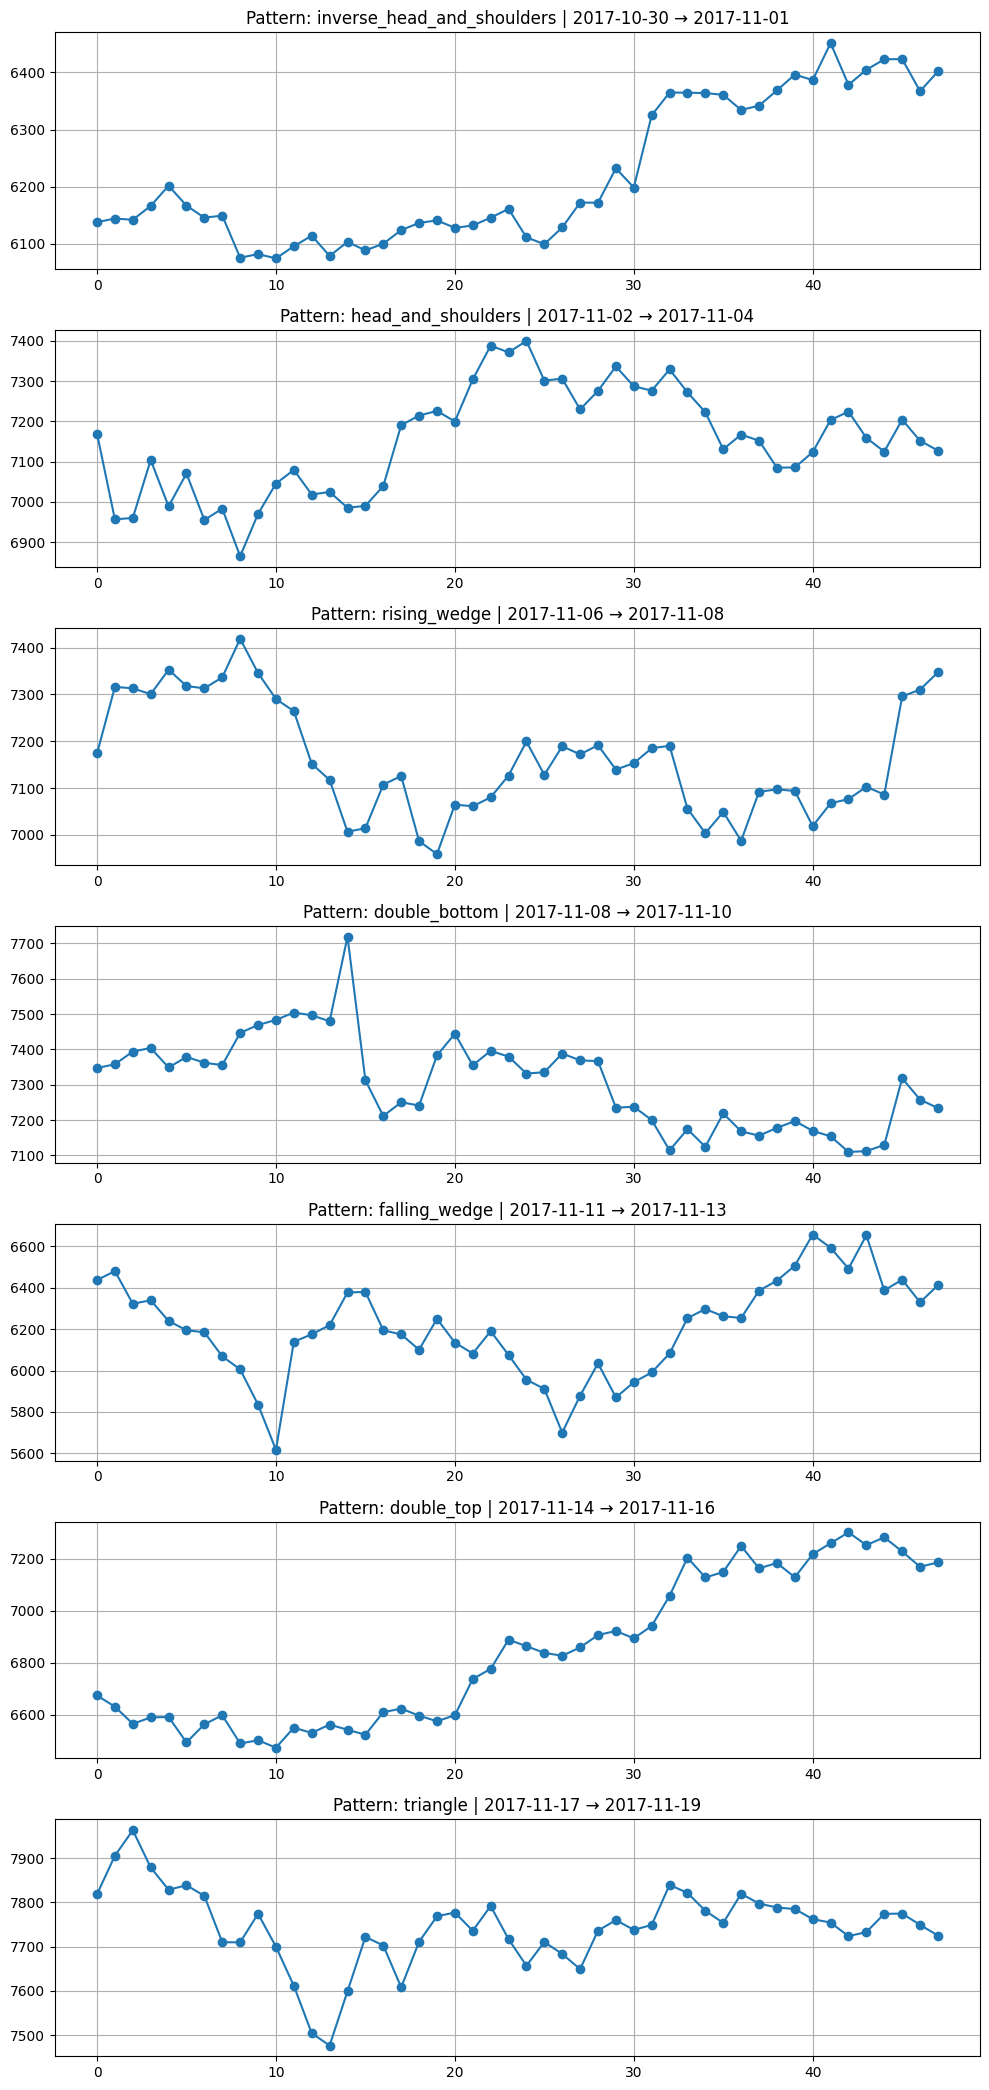

In [24]:
examples = pattern_df_hours[pattern_df_hours['label'] != 'none'].groupby('label').head(1)

fig, axs = plt.subplots(len(examples), 1, figsize=(10, 3 * len(examples)))

if len(examples) == 1:
    axs = [axs]

for ax, (_, row) in zip(axs, examples.iterrows()):
    window = np.array(row['window'])
    ax.plot(window, marker='o')
    ax.set_title(f"Pattern: {row['label']} | {row['start'].date()} → {row['end'].date()}")
    ax.grid(True)

plt.tight_layout()
plt.show()

Сбалансируем классы, для того, чтобы модель не переобучалась на классе none.

In [ ]:
from sklearn.utils import resample


def balance(df,min_required):

  
   # Минимум, чтобы не включать совсем редкие паттерны
    target_count= df['label'].value_counts().drop("none").max()

    balanced_df = []

    for label, group in df.groupby("label"):
        n = len(group)

        if label == "none":
            # undersample "none"
            sampled = group.sample(n=target_count, random_state=42)
        elif n >= min_required:
            # oversample (или просто оставить) остальные
            sampled = resample(group, replace=True, n_samples=target_count, random_state=42)
        else:
            print(f"⚠️ Пропущено слишком мало примеров: {label} ({n})")
            continue

        balanced_df.append(sampled)

    # Объединение и сохранение
    balanced_df = pd.concat(balanced_df).sample(frac=1, random_state=42).reset_index(drop=True)


    # Показать результат
    print("✅ Балансировка завершена:")
    print(balanced_df['label'].value_counts())
    return(balanced_df)

balanced_df_all_days=balance(pattern_df_hours,50)


✅ Балансировка завершена:
label
head_and_shoulders            7235
double_bottom                 7235
inverse_head_and_shoulders    7235
none                          7235
triangle                      7235
falling_wedge                 7235
rising_wedge                  7235
double_top                    7235
Name: count, dtype: int64


Я буду использовать AutoModelForSequenceClassification, поскольку она позволяет работать с последовательностями данных и находить в них закономерности.

c:\Users\User\anaconda3\envs\ta-patterns\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


label
head_and_shoulders            7235
double_bottom                 7235
inverse_head_and_shoulders    7235
none                          7235
triangle                      7235
falling_wedge                 7235
rising_wedge                  7235
double_top                    7235
Name: count, dtype: int64


Map: 100%|██████████| 57880/57880 [00:07<00:00, 7281.40 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\User\AppData\Local\Temp\ipykernel_9512\2622703530.py:99: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,1.520500,0.933126,0.685988
2,0.791200,0.670273,0.764686
3,0.589700,0.556827,0.799499
4,0.471300,0.427786,0.853576
5,0.379900,0.395363,0.866275
6,0.304000,0.284195,0.904544
7,0.229300,0.281712,0.914737
8,0.176600,0.273131,0.921735
9,0.144500,0.263395,0.928473
10,0.118700,0.258560,0.938925


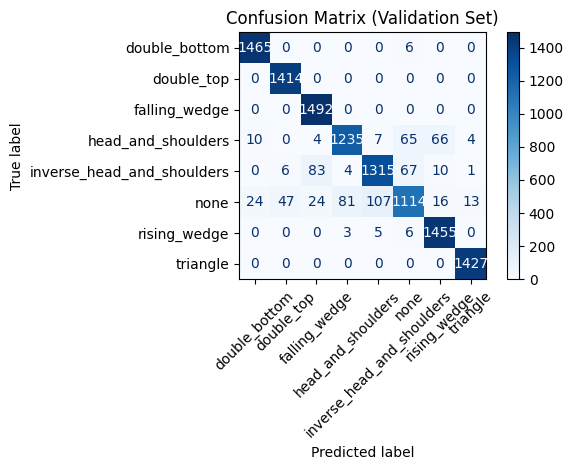


📊 Classification Report:
                            precision    recall  f1-score   support

             double_bottom       0.98      1.00      0.99      1471
                double_top       0.96      1.00      0.98      1414
             falling_wedge       0.93      1.00      0.96      1492
        head_and_shoulders       0.93      0.89      0.91      1391
inverse_head_and_shoulders       0.92      0.88      0.90      1486
                      none       0.89      0.78      0.83      1426
              rising_wedge       0.94      0.99      0.96      1469
                  triangle       0.99      1.00      0.99      1427

                  accuracy                           0.94     11576
                 macro avg       0.94      0.94      0.94     11576
              weighted avg       0.94      0.94      0.94     11576



In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    EarlyStoppingCallback
)
from scipy.special import softmax
from datasets import Dataset
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import os

#  Загрузка сбалансированных данных
df = balanced_df_all_days.copy()
print(df['label'].value_counts())

#  Преобразуем окна в текст 
def normalize(seq):
    arr = np.array(seq)
    return (arr - arr.mean()) / (arr.std() + 1e-6)

# сделаем так, чтобы модель также искала позицию ближе к правому краю
def positional_hint(seq):
    arr = np.array(seq)
    key_idx = np.argmax(np.abs(arr - arr.mean()))  # точка с максимальным отклонением от среднего
    relative_pos = key_idx / len(seq)              # в долях от 0 (лево) до 1 (право)
    return f"pos:{1 - relative_pos:.2f}"            # ближе к 1 — ближе к правому краю

df['input_text'] = df['window'].apply(lambda x: f"{positional_hint(x)} " + " ".join([f"{v:.3f}" for v in normalize(x)]))



# Кодировка меток 
le = LabelEncoder()
df['labels'] = le.fit_transform(df['label'])  

label2id = {l: i for i, l in enumerate(le.classes_)}
id2label = {i: l for l, i in label2id.items()}

# Hugging Face Dataset
dataset = Dataset.from_pandas(df[['input_text', 'labels']])

#  Токенизация 
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(example):
    return tokenizer(example["input_text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# Модель 
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Accuracy функция 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.from_numpy(logits).argmax(dim=1).numpy()
    return {"accuracy": accuracy_score(labels, preds)}

# Аргументы обучения
training_args = TrainingArguments(
    output_dir="./model_out",
    eval_strategy="epoch",         # Оцениваем каждую эпоху
    logging_strategy="epoch",            # Логгируем тоже по эпохам
    save_strategy="epoch",               # Сохраняем чекпойнт каждый раз
    save_total_limit=2,                  # Храним только 2 последних
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",    # Или f1-score, если используешь
    greater_is_better=True,

    per_device_train_batch_size=32,      # Больше = быстрее (если GPU позволяет)
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,       # Можешь повысить, если мало памяти
    num_train_epochs=50,                 # 30 → можно снизить, если есть EarlyStopping
    weight_decay=0.01,
    learning_rate=2e-5,                  # Лучше явно задать (default: 5e-5)
    warmup_ratio=0.1,                    # Постепенное включение обучения
    fp16=True,                           # Ускорение на GPU
    seed=42,                             # Для воспроизводимости

    logging_dir="./logs",
    report_to="none",                    # отключить W&B, TensorBoard и т.п.
)


# Trainer с Early Stopping
trainer = Trainer(
    model=model,
    
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

#  Обучение 
trainer.train()

# Сохранение модели 
model.save_pretrained("pattern-classifier-hours-btc")
tokenizer.save_pretrained("pattern-classifier-hours-btc")

#  Получение предсказаний на валидации 
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)
# Получение вероятностей (softmax) и уверенности
probs = softmax(predictions.predictions, axis=1)  # (N, num_classes)
confidences = probs.max(axis=1) 

# Матрица ошибок 
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# Полный отчёт по классам
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

Я сделаю более сложный вариант файн тюнинга с weighted trainer, поскольку метки классов имеют разную частоту в реальных примерах. Добавлю  рассчет confidence, чтобы отсеивать предсказания в которых модель не уврена. Также был добавлен R-Drop, он создаёт случайные "вариации" выхода, что снижает переобучение. И использована KL-дивергенция в качестве регуляризатора.



label
none                          47443
inverse_head_and_shoulders     7160
head_and_shoulders             6926
double_top                     1179
rising_wedge                   1111
falling_wedge                  1062
double_bottom                   904
triangle                        200
Name: count, dtype: int64

📊 Class Weights:
  double_bottom             → weight: 9.124
  double_top                → weight: 6.996
  falling_wedge             → weight: 7.767
  head_and_shoulders        → weight: 1.191
  inverse_head_and_shoulders → weight: 1.152
  none                      → weight: 0.174
  rising_wedge              → weight: 7.424
  triangle                  → weight: 41.241


Map: 100%|██████████| 65985/65985 [00:08<00:00, 8102.09 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\User\AppData\Local\Temp\ipykernel_9512\4263342261.py:73: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `RDropWeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.686900,1.276518,0.317951
2,1.122800,1.003686,0.384406
3,0.987800,0.901620,0.497765
4,0.915200,0.971175,0.562325
5,0.868700,0.900597,0.548913
6,0.804000,0.871079,0.583087
7,0.728700,0.825891,0.574221
8,0.633600,0.826153,0.551034
9,0.549800,0.947391,0.666288
10,0.466900,0.919510,0.621050


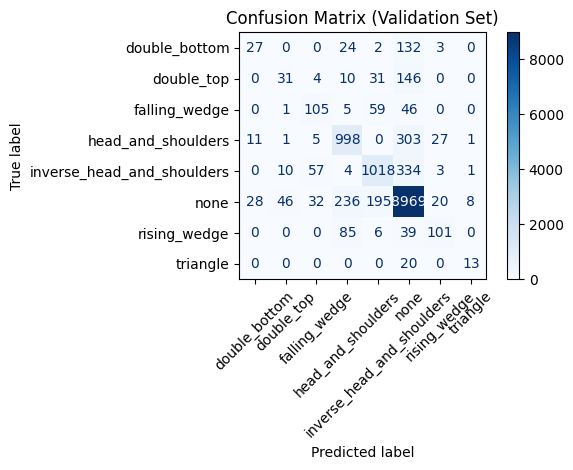


📊 Classification Report:
                            precision    recall  f1-score   support

             double_bottom       0.41      0.14      0.21       188
                double_top       0.35      0.14      0.20       222
             falling_wedge       0.52      0.49      0.50       216
        head_and_shoulders       0.73      0.74      0.74      1346
inverse_head_and_shoulders       0.78      0.71      0.74      1427
                      none       0.90      0.94      0.92      9534
              rising_wedge       0.66      0.44      0.52       231
                  triangle       0.57      0.39      0.46        33

                  accuracy                           0.85     13197
                 macro avg       0.61      0.50      0.54     13197
              weighted avg       0.84      0.85      0.84     13197



In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    EarlyStoppingCallback
)
from torch.nn import CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight
from scipy.special import softmax
from datasets import Dataset
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import os
import torch.nn.functional as F


# Функция kl-дивергенции
def kl_divergence(p_logits, q_logits):
    p_log_prob = F.log_softmax(p_logits, dim=-1)
    q_log_prob = F.log_softmax(q_logits, dim=-1)

    p_prob = F.softmax(p_logits, dim=-1)
    q_prob = F.softmax(q_logits, dim=-1)

    # Симметричная KL-дивергенция
    kl_pq = F.kl_div(p_log_prob, q_prob, reduction='batchmean')
    kl_qp = F.kl_div(q_log_prob, p_prob, reduction='batchmean')
    return (kl_pq + kl_qp) / 2

# Загрузка сбалансированных данных 
df = pattern_df_hours.copy()
print(df['label'].value_counts())

# Посчитаем веса
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

# Печатаем веса классов с названиями
print("\n📊 Class Weights:")
for label_id, weight in enumerate(class_weights):
    label_name = le.inverse_transform([label_id])[0]
    print(f"  {label_name:<25} → weight: {weight:.3f}")

# Преобразуем окна в текст 
def normalize(seq):
    arr = np.array(seq)
    return (arr - arr.mean()) / (arr.std() + 1e-6)

# сделаем так, чтобы модель также искала позицию ближе к правому краю
def positional_hint(seq):
    arr = np.array(seq)
    key_idx = np.argmax(np.abs(arr - arr.mean()))  # точка с максимальным отклонением от среднего
    relative_pos = key_idx / len(seq)              # в долях от 0 (лево) до 1 (право)
    return f"pos:{1 - relative_pos:.2f}"            # ближе к 1 — ближе к правому краю

df['input_text'] = df['window'].apply(
    lambda x: " ".join([f"{v:.3f}" for v in normalize(x)])
)

#Сделаем класс для тренера с весами и r-drop
class RDropWeightedTrainer(Trainer):
    def __init__(self, *args, alpha=0.5, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha
        self.class_weights = class_weights.to(self.args.device) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Для Multi-Task:
        pos_labels = inputs.get("pos_labels", None)

        # Первый и второй проход
        outputs1 = model(**inputs)
        outputs2 = model(**inputs)

        logits1 = outputs1.get("logits")
        logits2 = outputs2.get("logits")

        # Потери
        loss_fct = CrossEntropyLoss(weight=self.class_weights) if self.class_weights is not None else CrossEntropyLoss()
        ce_loss1 = loss_fct(logits1, labels)
        ce_loss2 = loss_fct(logits2, labels)
        kl_loss = kl_divergence(logits1, logits2)

        loss = (ce_loss1 + ce_loss2) / 2 + self.alpha * kl_loss

        if return_outputs:
            return loss, outputs1
        return loss
#Кодировка меток 
le = LabelEncoder()
df['labels'] = le.fit_transform(df['label'])  

label2id = {l: i for i, l in enumerate(le.classes_)}
id2label = {i: l for l, i in label2id.items()}

# Hugging Face Dataset 
dataset = Dataset.from_pandas(df[['input_text', 'labels']])

#  Токенизация 
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(example):
    return tokenizer(example["input_text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

#  Модель 
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Accuracy функция 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.from_numpy(logits).argmax(dim=1).numpy()
    return {"accuracy": accuracy_score(labels, preds)}

#Аргументы обучения 
training_args = TrainingArguments(
    output_dir="./model_out",
    eval_strategy="epoch",         # Оцениваем каждую эпоху
    logging_strategy="epoch",            # Логгируем тоже по эпохам
    save_strategy="epoch",               # Сохраняем чекпойнт каждый раз
    save_total_limit=2,                  # Храним только 2 последних
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",    # Или f1-score, если используешь
    greater_is_better=True,

    per_device_train_batch_size=32,      # Больше = быстрее (если GPU позволяет)
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=1,       # Можешь повысить, если мало памяти
    num_train_epochs=50,                 # 30 → можно снизить, если есть EarlyStopping
    weight_decay=0.01,
    learning_rate=2e-5,                  # Лучше явно задать (default: 5e-5)
    warmup_ratio=0.1,                    # Постепенное включение обучения
    fp16=True,                           # Ускорение на GPU
    seed=42,                             # Для воспроизводимости

    logging_dir="./logs",
    report_to="none",                    # отключить W&B, TensorBoard и т.п.
)


# RdropWightedTrainer с Early Stopping
trainer = RDropWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)],
    alpha=0.5,
    class_weights=class_weights
)

# Обучение
trainer.train()

# Сохранение модели
model.save_pretrained("pattern-classifier-hours-btc-m")
tokenizer.save_pretrained("pattern-classifier-hours-btc-m")

# Получение предсказаний на валидации
predictions = trainer.predict(dataset["test"])
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)
# Получение вероятностей (softmax) и уверенности
probs = softmax(predictions.predictions, axis=1)  # (N, num_classes)
confidences = probs.max(axis=1) 

# Матрица ошибок 
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# Полный отчёт по классам
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

In [2]:
df=df_hours.copy()

Сделаем проверку на всем датасете для обоих моделей

In [42]:
df=pd.read_csv(r"C:\Users\User\my\py\practise\price_btc\BTC_price_hours.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1062813235.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\User\my\py\practise\price_btc\BTC_price_hours.csv")


Map: 100%|██████████| 65985/65985 [00:08<00:00, 8018.17 examples/s]


✅ Разметка завершена.
label
none                          47443
inverse_head_and_shoulders     7160
head_and_shoulders             6926
double_top                     1179
rising_wedge                   1111
falling_wedge                  1062
double_bottom                   904
triangle                        200
Name: count, dtype: int64
                            precision    recall  f1-score   support

             double_bottom       0.16      0.41      0.23       904
                double_top       0.15      0.41      0.22      1179
             falling_wedge       0.25      0.57      0.35      1062
        head_and_shoulders       0.53      0.65      0.58      6926
inverse_head_and_shoulders       0.53      0.69      0.60      7160
                      none       0.91      0.71      0.79     47443
              rising_wedge       0.31      0.73      0.43      1111
                  triangle       0.29      0.96      0.45       200

                  accuracy                  

,start,end,predicted_label,confidence,prob_double_bottom,prob_double_top,prob_falling_wedge,prob_head_and_shoulders,prob_inverse_head_and_shoulders,prob_none,prob_rising_wedge,prob_triangle,label,predicted_label_conf
0,2017-10-30 06:00:00,2017-11-01 05:00:00,inverse_head_and_shoulders,0.661414,0.000217,0.331134,0.000307,0.000158,0.661414,0.006624,0.000051,0.000093,inverse_head_and_shoulders,none
1,2017-10-30 07:00:00,2017-11-01 06:00:00,inverse_head_and_shoulders,0.991312,0.000020,0.000103,0.000072,0.000038,0.991312,0.008430,0.000016,0.000009,inverse_head_and_shoulders,inverse_head_and_shoulders
2,2017-10-30 08:00:00,2017-11-01 07:00:00,inverse_head_and_shoulders,0.999462,0.000011,0.000023,0.000040,0.000013,0.999462,0.000431,0.000012,0.000009,none,inverse_head_and_shoulders
3,2017-10-30 09:00:00,2017-11-01 08:00:00,inverse_head_and_shoulders,0.966745,0.000025,0.010885,0.000116,0.000247,0.966745,0.021616,0.000199,0.000167,none,inverse_head_and_shoulders
4,2017-10-30 10:00:00,2017-11-01 09:00:00,double_top,0.924899,0.000047,0.924899,0.000042,0.000053,0.000949,0.073928,0.000042,0.000039,inverse_head_and_shoulders,double_top
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65980,2025-05-10 10:00:00,2025-05-12 09:00:00,none,0.979370,0.000006,0.000017,0.000011,0.020487,0.000079,0.979370,0.000022,0.000010,none,none
65981,2025-05-10 11:00:00,2025-05-12 10:00:00,none,0.919678,0.000009,0.000010,0.000076,0.079719,0.000430,0.919678,0.000062,0.000017,none,none
65982,2025-05-10 12:00:00,2025-05-12 11:00:00,none,0.858559,0.000008,0.000060,0.000063,0.141132,0.000155,0.858559,0.000014,0.000008,head_and_shoulders,none
65983,2025-05-10 13:00:00,2025-05-12 12:00:00,none,0.999436,0.000003,0.000010,0.000009,0.000503,0.000024,0.999436,0.000013,0.000003,none,none


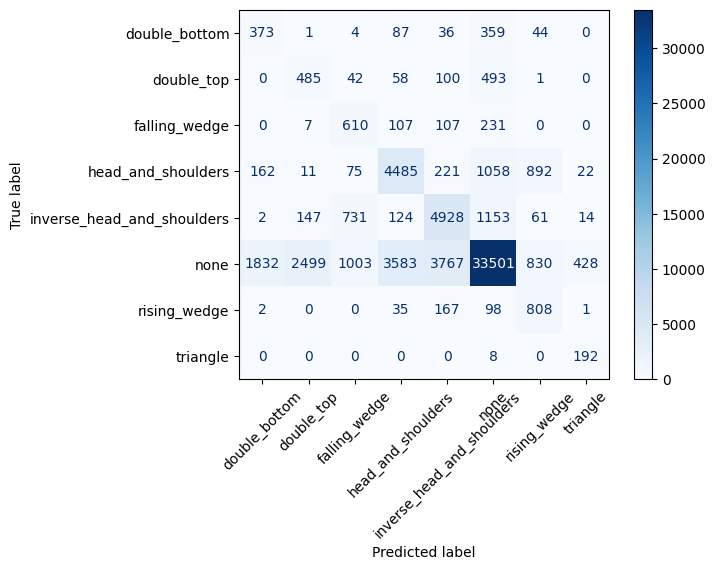

In [43]:
#Первоначальная модель
import numpy as np
import pandas as pd
import torch
import time
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
)
from torch.utils.data import DataLoader
import torch.nn.functional as F
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_prediction(df, model_dir="pattern-classifier-hours-btc"):


    def predict_with_confidence(df, window_size=48, step=1):
        df = df.copy()
        df['time'] = pd.to_datetime(df['time'])
        series = df['close'].values
        dates = df['time'].values

        # 1. Формируем окна
        windows, start_times, end_times = [], [], []
        for i in range(0, len(series) - window_size, step):
            window = series[i:i + window_size]
            windows.append(window)
            start_times.append(dates[i])
            end_times.append(dates[i + window_size - 1])

        # 2. Нормализация
        def normalize(seq):
            arr = np.array(seq)
            return (arr - arr.mean()) / (arr.std() + 1e-6)

        texts = [" ".join([f"{v:.3f}" for v in normalize(w)]) for w in windows]
        df_texts = pd.DataFrame({"input_text": texts})

        # 3. Загрузка модели и токенизатора
        model = AutoModelForSequenceClassification.from_pretrained(model_dir)
        tokenizer = AutoTokenizer.from_pretrained(model_dir)
        id2label = model.config.id2label

        # 4. Токенизация
        dataset = Dataset.from_pandas(df_texts)
        dataset = dataset.map(lambda x: tokenizer(x["input_text"], truncation=True, padding="max_length", max_length=128), batched=True)
        dataset = dataset.remove_columns(["input_text"])
        dataset.set_format("torch")
        
        # 5. DataLoader
        dataloader = DataLoader(dataset, batch_size=32, collate_fn=DataCollatorWithPadding(tokenizer))

        # 6. Предсказания
        model.eval()
        model.to("cuda" if torch.cuda.is_available() else "cpu")
        all_preds, all_confs, all_probs = [], [], []

        with torch.no_grad():
            for batch in dataloader:
                batch = {k: v.to(model.device) for k, v in batch.items()}
                outputs = model(**batch)
                probs = F.softmax(outputs.logits, dim=1)
                confs, preds = torch.max(probs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_confs.extend(confs.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # 7. Сбор результатов
        pred_labels = [id2label[i] for i in all_preds]

        result_df = pd.DataFrame({
            "start": start_times,
            "end": end_times,
            "predicted_label": pred_labels,
            "confidence": all_confs
        })

        # Можно добавить все вероятности по классам
        prob_df = pd.DataFrame(all_probs, columns=[f"prob_{id2label[i]}" for i in range(len(id2label))])
        result_df = pd.concat([result_df, prob_df], axis=1)

        return result_df

    predicted_labels=predict_with_confidence(df)
    pattern_df=razmetka(df,48,0.02)
    predicted_labels['label']=pattern_df['label']
    predicted_labels['predicted_label_conf']=predicted_labels['predicted_label']
    #отнесем предсказания, в которых модель не увверена к none
    predicted_labels.loc[predicted_labels['confidence'] <= 0.8, 'predicted_label_conf'] = 'none'
    y_true = predicted_labels["label"]
    y_pred = predicted_labels["predicted_label"]

    # 2. Классификационный отчёт
    print(classification_report(y_true, y_pred))

    # 3. Матрица ошибок
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_true.unique()))
    disp.plot(xticks_rotation=45, cmap="Blues")


    return(predicted_labels)

evaluate_prediction(df)



Модель с weighted r-drop

Map: 100%|██████████| 65985/65985 [00:08<00:00, 7569.19 examples/s]


✅ Разметка завершена.
label
none                          47443
inverse_head_and_shoulders     7160
head_and_shoulders             6926
double_top                     1179
rising_wedge                   1111
falling_wedge                  1062
double_bottom                   904
triangle                        200
Name: count, dtype: int64
                            precision    recall  f1-score   support

             double_bottom       0.95      0.82      0.88       904
                double_top       0.94      0.84      0.89      1179
             falling_wedge       0.90      0.90      0.90      1062
        head_and_shoulders       0.95      0.95      0.95      6926
inverse_head_and_shoulders       0.96      0.94      0.95      7160
                      none       0.98      0.99      0.98     47443
              rising_wedge       0.95      0.88      0.91      1111
                  triangle       0.95      0.90      0.92       200

                  accuracy                  

,start,end,predicted_label,confidence,prob_double_bottom,prob_double_top,prob_falling_wedge,prob_head_and_shoulders,prob_inverse_head_and_shoulders,prob_none,prob_rising_wedge,prob_triangle,label,predicted_label_conf
0,2017-10-30 06:00:00,2017-11-01 05:00:00,inverse_head_and_shoulders,0.999985,7.375334e-07,4.112078e-06,1.436650e-06,1.292839e-06,0.999985,0.000002,1.323326e-06,3.198000e-06,inverse_head_and_shoulders,inverse_head_and_shoulders
1,2017-10-30 07:00:00,2017-11-01 06:00:00,inverse_head_and_shoulders,0.999991,3.738080e-07,3.878117e-07,6.504168e-07,5.320662e-07,0.999991,0.000005,8.739871e-07,8.908876e-07,inverse_head_and_shoulders,inverse_head_and_shoulders
2,2017-10-30 08:00:00,2017-11-01 07:00:00,none,0.999925,5.387483e-06,1.147181e-05,1.347207e-07,1.425267e-05,0.000042,0.999925,1.036756e-06,4.508854e-07,none,none
3,2017-10-30 09:00:00,2017-11-01 08:00:00,none,0.999784,2.190033e-06,1.687563e-04,1.814501e-07,1.602139e-05,0.000027,0.999784,1.783499e-06,6.185879e-07,none,none
4,2017-10-30 10:00:00,2017-11-01 09:00:00,inverse_head_and_shoulders,0.999991,1.921997e-07,1.131227e-06,1.171564e-06,8.851684e-07,0.999991,0.000003,1.358211e-06,1.659990e-06,inverse_head_and_shoulders,inverse_head_and_shoulders
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65980,2025-05-10 10:00:00,2025-05-12 09:00:00,none,0.999958,1.167192e-06,4.310804e-06,3.820073e-07,2.673974e-05,0.000008,0.999958,8.496681e-07,8.366260e-07,none,none
65981,2025-05-10 11:00:00,2025-05-12 10:00:00,none,0.999965,1.355955e-06,3.878156e-06,3.951086e-07,2.172313e-05,0.000006,0.999965,9.151276e-07,7.794219e-07,none,none
65982,2025-05-10 12:00:00,2025-05-12 11:00:00,head_and_shoulders,0.999973,4.839492e-07,1.868851e-06,2.105528e-06,9.999729e-01,0.000001,0.000019,1.032197e-06,1.578993e-06,head_and_shoulders,head_and_shoulders
65983,2025-05-10 13:00:00,2025-05-12 12:00:00,none,0.999938,1.279896e-06,2.988680e-06,6.537812e-07,4.991048e-05,0.000006,0.999938,8.958656e-07,8.114159e-07,none,none


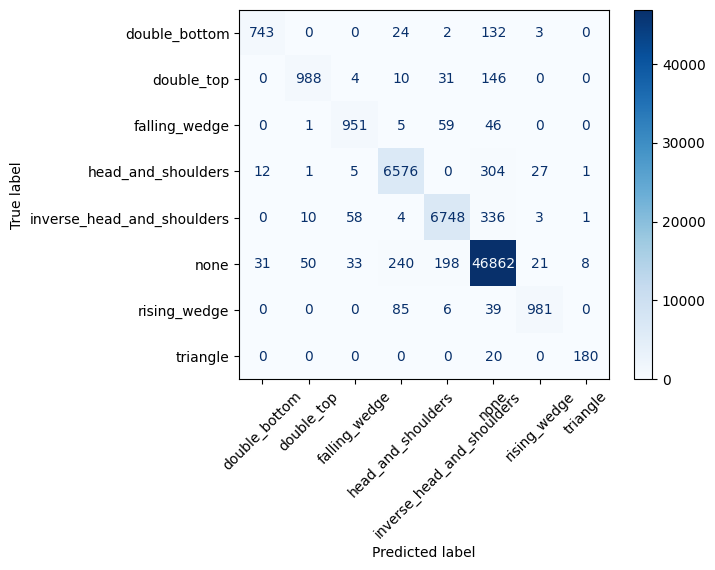

In [15]:
evaluate_prediction(df,model_dir='pattern-classifier-hours-btc-m')

Можно увидеть, что модель с weighted r-drop обладает гораздо большей точностью на всей выборке(0.39 macro против 0.95 macro). В первую очередь это связано с тем, что модель, обученная на сбалансированном датасете, не отражает реальную частоту и дает много ложных сигналов (распознает паттерны там, где none). Таким образом более целесообразным будет использовать вторую модель.